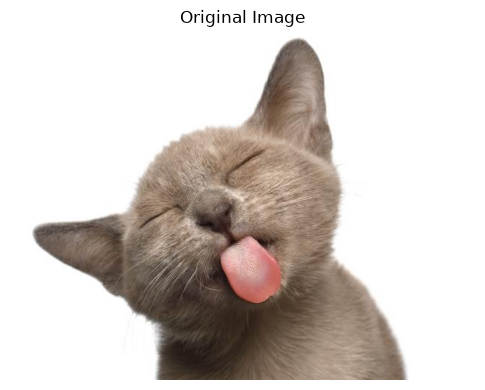

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read Image
image_path = r"E:\Open CV\Module 13 - Geometric Transformations\Images\sample.jpg"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found!")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

### Affine Transformation Example

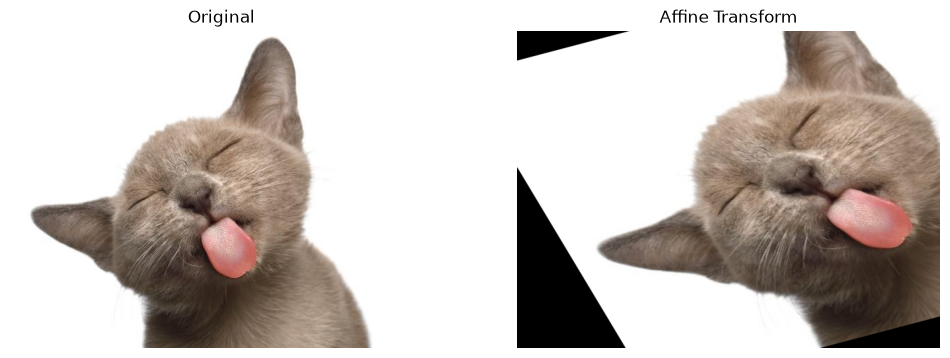

In [2]:
# Get image size
rows, cols = image.shape[:2]

# Source Points (3 Points)
pts1 = np.float32([
    [50,50],
    [200,50],
    [50,200]
])

# Destination Points
pts2 = np.float32([
    [10,100],
    [200,50],
    [100,250]
])

# Affine Matrix
matrix = cv2.getAffineTransform(pts1, pts2)

# Apply Transformation
affine = cv2.warpAffine(image, matrix, (cols, rows))

# Convert to RGB
affine_rgb = cv2.cvtColor(affine, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(affine_rgb)
plt.title("Affine Transform")
plt.axis("off")

plt.show()

### Perspective Transformation Example

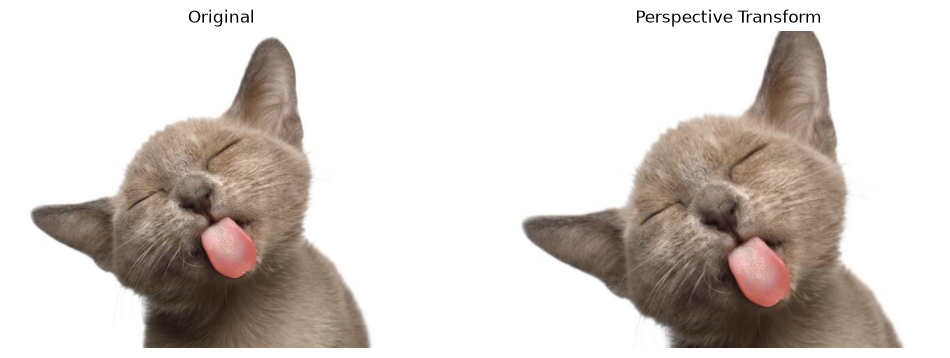

In [3]:
rows, cols = image.shape[:2]

# Four source points
src = np.float32([
    [50,50],
    [cols-50,50],
    [50,rows-50],
    [cols-50,rows-50]
])

# Four destination points
dst = np.float32([
    [0,0],
    [cols,50],
    [50,rows],
    [cols,rows]
])

# Perspective Matrix
matrix = cv2.getPerspectiveTransform(src, dst)

# Warp
perspective = cv2.warpPerspective(image, matrix, (cols, rows))

perspective_rgb = cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(perspective_rgb)
plt.title("Perspective Transform")
plt.axis("off")

plt.show()

### Homography Example

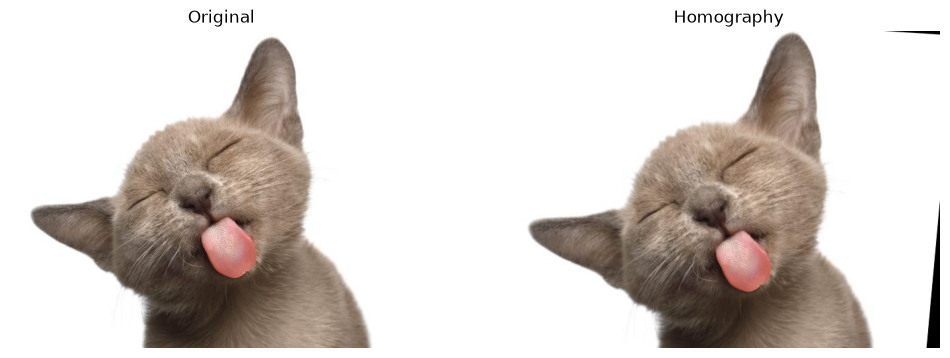

In [4]:
# Create second image using Perspective Transform
rows, cols = image.shape[:2]

src_pts = np.float32([
    [50,50],
    [cols-50,50],
    [50,rows-50],
    [cols-50,rows-50]
])

dst_pts = np.float32([
    [20,30],
    [cols-30,60],
    [50,rows-20],
    [cols-60,rows-40]
])

# Find Homography Matrix
H, mask = cv2.findHomography(src_pts, dst_pts)

# Warp using Homography
homography = cv2.warpPerspective(image, H, (cols, rows))

homography_rgb = cv2.cvtColor(homography, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(homography_rgb)
plt.title("Homography")
plt.axis("off")

plt.show()